In [1]:
from baselines.IPPO import ippo_ff_mpe, ippo_rnn_mpe
from baselines.MAPPO import mappo_rnn_mpe
import importlib.resources as resources
import yaml
from omegaconf import OmegaConf
import os
os.environ["WANDB_NOTEBOOK_NAME"] = "Playground.ipynb"

ERROR:2025-10-01 23:38:33,640:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dbraga/.conda/envs/condaenv/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dbraga/.conda/envs/condaenv/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 334, in initialize
    c_api = xb.register_plugin(
            ^^^^^^^^^^^^^^^^^^^
  File "/home/dbraga/.conda/envs/condaenv/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 621, in register_plugin
    c_api = xla_client.load_pjrt_plugin_dynamically(plugin_name, library_path)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dbraga/.conda/envs/condaenv/lib/python3.11/site-packages/jaxlib/xla_client.py", line 113, in load_pjrt_plugin_dynamically
    return _xla.load_pjrt_plugin(plugin_na

Failed to import warp: No module named 'warp'
Failed to import mujoco.mjx.third_party.mujoco_warp as mujoco_warp: No module named 'warp'


In [2]:
import jax
jax.devices()

[CudaDevice(id=0)]

In [7]:
algo_and_config_map = {
    "ippo_ff_mpe": (ippo_ff_mpe, OmegaConf.load(resources.files("baselines.IPPO.config") / "ippo_ff_mpe.yaml")),
    "ippo_rnn_mpe": (ippo_rnn_mpe, OmegaConf.load(resources.files("baselines.IPPO.config") / "ippo_rnn_mpe.yaml")),
    "mappo_rnn_mpe": (mappo_rnn_mpe, OmegaConf.load(resources.files("baselines.MAPPO.config") / "mappo_homogenous_rnn_mpe.yaml"))
}

CPU times: user 2min 58s, sys: 302 ms, total: 2min 59s
Wall time: 3min 2s


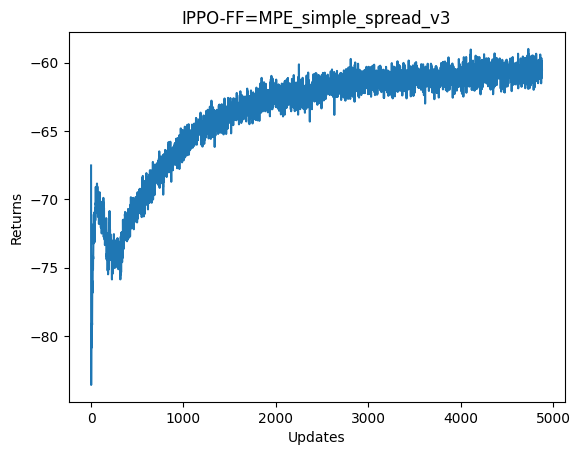

In [8]:
%%time
ALGO_NAME = "ippo_ff_mpe"
algo, config = algo_and_config_map[ALGO_NAME]
algo.main(config)

In [9]:
%%time
ALGO_NAME = "ippo_rnn_mpe"
algo, config = algo_and_config_map[ALGO_NAME]
algo.main(config)

W1001 23:44:52.797170 2876166 gemm_fusion_autotuner.cc:1053] Compiling 258 configs for 19 fusions on a single thread.


CPU times: user 7min 26s, sys: 3min 5s, total: 10min 31s
Wall time: 10min 56s


In [10]:
%%time
ALGO_NAME = "mappo_rnn_mpe"
algo, config = algo_and_config_map[ALGO_NAME]
algo.main(config)

W1001 23:55:50.298816 2876166 gemm_fusion_autotuner.cc:1053] Compiling 150 configs for 16 fusions on a single thread.


CPU times: user 40min 12s, sys: 18min 58s, total: 59min 11s
Wall time: 59min 33s
